In [1]:
import numpy as np
from math import pi
from matplotlib import pyplot as plt
from algorithms.geometry.shapes import GeometryBase, Polygon

In [ ]:
"""
TODO
- change points to vertices
- change GeometryBase to Shape 
- Clean up the numba files 

"""


'\nTODO\n- change points to vertices\n- change GeometryBase to Shape \n- Clean up the numba files \n\n'

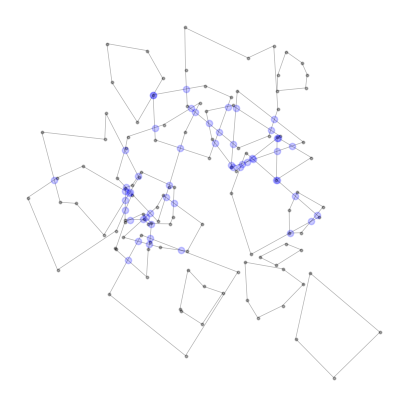

In [117]:
# Random polygons

def generate_random_polygons(num_polygons: int, randomness: float=0.1):

    polygons = []
    for i in range(num_polygons):
        midpoint = np.random.uniform(0,1,2)
        rad = np.random.uniform(0.05, 0.2)
        num_points = np.random.randint(3,10)
        a = np.linspace(0, 2*pi, num_points, endpoint=False)
        points = midpoint + np.multiply(rad, [np.cos(a), np.sin(a)]).T
        points = points + np.random.uniform(-rad*randomness, rad*randomness, (num_points, 2))
        polygons.append(Polygon(points))

    return polygons


def plot_polygon(ax, polygon):
    points = np.vstack((polygon.points, polygon.points[0]))
    ax.plot(*points.T, color="black", alpha=0.3, linewidth=0.5)
    ax.scatter(*polygon.points.T, color="black", s=3, alpha=0.3, zorder=100)


def plot_polygon_list(ax, polygons):
    for pol in polygons:
        plot_polygon(ax, pol)
    

def plot_intersections(ax, intersections):
    ax.scatter(*intersections.T, color="blue", s=20, alpha=0.2, zorder=200)


def get_intersections(polygons):
    n = len(polygons)
    intersections = []
    for i in range(n):
        for j in range(n):
            if i >= j:
                continue
            intersect = polygons[i].intersect_pol(polygons[j])
            if np.isnan(intersect).all():
                continue
            intersections.append(intersect)
    return np.vstack(intersections)

        
polygons = generate_random_polygons(20, randomness=0.5)
intersections = get_intersections(polygons)

fig, ax = plt.subplots(figsize=(5,5))

plot_polygon_list(ax, polygons)
plot_intersections(ax, intersections)

ax.set_axis_off()
plt.show()
